# Human-aligned cheat detector (Maia2 embeddings) — **multi-cheat sweep (2-class, 6 bins)**

This notebook trains a simple **MLP** to classify move outcomes into **3 classes**:

- `y=0`: human move (improvable and unimprovable)
- `y=1`: cheated move

For each **cheat model** (and an extra **ALL** mixture column), we:

1. Build a 2-class dataset from `move_before`, `move_uci` and `move_{cheat_model}`.
2. Train with early stopping & LR scheduling on **validation cheat-class F1**.
3. Calibrate a **decision threshold** for cheat class on validation to maximize cheat F1.
4. Evaluate on **TEST** per rating-bin (6 bins) and **ALL**.

Artifacts are saved under `OUT_DIR`:
- `models/<cheat_name>/<run_id>/model.pt` + `meta.json`
- `curves/<cheat_name>/<run_id>.csv`
- `tables/metrics__<metric>.csv`
- `tables/selected_models.csv`


In [1]:
# === Imports / seeds ===
from __future__ import annotations

import json
import math
import os
import random
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report

# Repro
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
# === spec ===

# hard-code bins and their order
BIN_NAMES: List[str] = [
    "lt_1200",
    "1200-1400",
    "1400-1600",
    "1600-1800",
    "1800-2000",
    "2000-2200",
]
BIN_NAME_TO_IDX: Dict[str, int] = {b: i for i, b in enumerate(BIN_NAMES)}

# Model name -> allowed bin indices.
# The cheat FEN column is assumed to be: f"fen_{model_name}".
CHEAT_MODEL_TO_BIN_IDXS: Dict[str, List[int]] = {
    "stockfish_1":   list(range(6)),
    "stockfish_5":   list(range(6)),
    "stockfish_9":   list(range(6)),
    "stockfish_11":  list(range(6)),
    "stockfish_15":  list(range(6)),
    "lc0_1":         list(range(6)),
    "lc0_10":        list(range(6)),
    "lc0_100":       list(range(6)),
}

CHEAT_NAMES = list(CHEAT_MODEL_TO_BIN_IDXS.keys())
CHEAT_FEN_COLS = [f"fen_{name}" for name in CHEAT_NAMES]

# --- Experiment knobs ---
EXPR_CFG: Dict[str, Any] = {
    "split_col": "split_by_player",  # "split_by_player" | "split_by_games"
    "rating_bin_col": "rating_bin",

    # label definition
    "fen_before_col": "fen_before",
    "fen_after_col":  "fen_after",

    # "best" (used only to filter unimprovable rows: human_after == best_after)
    "best_fen_col": "fen_stockfish_15",

    # cheat column discovery rules (kept for clarity / consistency with other notebooks)
    "cheat_fen_prefix": "fen_",

    # feature combine mode for (before_emb, after_emb)
    #   - concat:   [e_before, e_after]
    #   - rich:     [e_before, e_after, |diff|, prod]
    #   - diffprod: [|diff|, prod]
    #   - mean:     (e_before + e_after) / 2
    "combine_mode": "concat",

    # internal val split from TRAIN rows (game-level split, per bin)
    "val_frac": 0.1,
}

# Required columns
CSV_COLS = [
    "half_move",
    "player_color",
    "is_used",
    EXPR_CFG["split_col"],
    EXPR_CFG["rating_bin_col"],
    EXPR_CFG["fen_before_col"],
    EXPR_CFG["fen_after_col"],
    EXPR_CFG["best_fen_col"],
    *CHEAT_FEN_COLS,
]

# NPZ must contain Maia2 embeddings for every needed FEN column
NPZ_COLS = [EXPR_CFG["fen_before_col"], EXPR_CFG["fen_after_col"], *CHEAT_FEN_COLS]

# --- Training defaults (per run) ---
TRAIN_CFG: Dict[str, Any] = {
    "epochs": 500,
    "early_stop_patience": 20
}

DEFAULT_FIXED_SPECS: Dict[str, Dict[str, Any]] = {
    #"mlp_001": {"hidden_dim": 1024, "act": "GELU", "norm": "batch", "drop": 0.1, "lr": 3e-4, "weight_decay": 3e-5},
    "mlp_002": {"hidden_dim": 256,  "act": "GELU", "norm": "batch", "drop": 0.0, "lr": 3e-4, "weight_decay": 3e-4},
    #"mlp_003": {"hidden_dim": 64,   "act": "GELU", "norm": "layer", "drop": 0.1, "lr": 3e-4, "weight_decay": 3e-8},
}

# How to pick the best run among the architectures (per cheat model)
# Main objective: maximize F1 of cheat class, using a validation-calibrated threshold.
# SELECT_BEST_BY = "val_f1_best"

# Threshold grid for cheat class calibration (val only)
THR_GRID = np.array([0.5])


In [3]:
# === Paths / outputs ===

def get_repo_root_git() -> Path:
    p = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
    return Path(p)

REPO_ROOT = get_repo_root_git()
print("REPO_ROOT:", REPO_ROOT)

# ---- Dataset ----
CSV_PATH = REPO_ROOT / "data/processed/6bins_small/04_final_dataset.csv"
EMB_NPZ = REPO_ROOT / "data/processed/13bins_small/04_embs_maia2_2050_full.npz"

# ---- Outputs ----
OUT_DIR = REPO_ROOT / "new_notebooks/new_reports/03_2cls_6bins" / "maia2_2050_concat"
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "curves").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

print("CSV_PATH:", CSV_PATH)
print("EMB_NPZ :", EMB_NPZ)
print("OUT_DIR :", OUT_DIR)


REPO_ROOT: /home/jovyan/artem/humanlike
CSV_PATH: /home/jovyan/artem/humanlike/data/processed/6bins_small/04_final_dataset.csv
EMB_NPZ : /home/jovyan/artem/humanlike/data/processed/13bins_small/04_embs_maia2_2050_full.npz
OUT_DIR : /home/jovyan/artem/humanlike/new_notebooks/new_reports/03_2cls_6bins/maia2_2050_concat


## Prepare dataset

In [4]:
# === Load data + sanity check ===

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
if not Path(EMB_NPZ).exists():
    raise FileNotFoundError(f"NPZ not found: {EMB_NPZ}")

df = pd.read_csv(CSV_PATH, index_col=0)  # CSV index stores the NPZ row id
df["npz_row"] = df.index

missing = [c for c in CSV_COLS if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns ({len(missing)}): {missing}")

# Validate bin names are exactly the fixed set.
bins_in_data = df[EXPR_CFG["rating_bin_col"]].unique()
if sorted(bins_in_data) != sorted(BIN_NAMES):
    raise ValueError(
        "Rating bins mismatch.\n"
        f"Expected exactly: {BIN_NAMES}\n"
        f"Found: {bins_in_data}"
    )

# Add stable bin index (0..5)
df["bin_idx"] = df[EXPR_CFG["rating_bin_col"]].map(BIN_NAME_TO_IDX)
print(f"CSV cols: {len(df.columns)}")

# Load NPZ keys (cheap) and keep the file handle for arrays.
npz = np.load(EMB_NPZ)
npz_keys = set(npz.files)

missing_npz = [c for c in NPZ_COLS if c not in npz_keys]
if missing_npz:
    raise KeyError(f"Missing embeddings in NPZ ({len(missing_npz)}): {missing_npz[:10]} ...")
print(f"NPZ keys: {len(npz_keys)}")

CSV cols: 247
NPZ keys: 59


In [5]:
df.head(5)

,player,game_id,rating_bin,split_by_player,split_by_games,player_color,player_elo,opponent_elo,time_control,half_move,...,eval_character_Smalldoc_2254,eval_character_alkhawaja111_2217,eval_character_fuegodejavu_2215,eval_character_jozarov_2323,eval_character_lindenice_2272,eval_character_nrm18_2369,eval_character_oberschlumpf_2261,eval_character_rmnp_2284,npz_row,bin_idx
853,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,853,5
854,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,854,5
855,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,855,5
856,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,856,5
857,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,857,5


In [6]:
# === Common row mask ===

print("is_used:", df["is_used"].value_counts(dropna=False).to_dict())

# df_filtered
df_f = df.loc[df["is_used"] == True].reset_index(drop=True)

is_used: {False: 657080, True: 417207}


In [7]:
df_f.head(5)

,player,game_id,rating_bin,split_by_player,split_by_games,player_color,player_elo,opponent_elo,time_control,half_move,...,eval_character_Smalldoc_2254,eval_character_alkhawaja111_2217,eval_character_fuegodejavu_2215,eval_character_jozarov_2323,eval_character_lindenice_2272,eval_character_nrm18_2369,eval_character_oberschlumpf_2261,eval_character_rmnp_2284,npz_row,bin_idx
0,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,21,...,6.0,6.0,6.0,-21.0,18.0,-11.0,6.0,-21.0,873,5
1,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,23,...,31.0,31.0,46.0,8.0,31.0,31.0,31.0,8.0,875,5
2,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,25,...,35.0,35.0,-9.0,35.0,35.0,35.0,35.0,35.0,877,5
3,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,27,...,-390.0,-312.0,-28.0,-28.0,-390.0,-28.0,-390.0,-28.0,879,5
4,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,29,...,-365.0,-365.0,-365.0,-365.0,-365.0,-365.0,-365.0,-365.0,881,5


In [8]:
def split_train_val_by_player_per_bin(
    df_f: pd.DataFrame,
    *,
    split_col: str,
    bin_idx_col: str,
    player_col: str,
    bin_names: List[str],
    val_frac: float,
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Row-level train/val split by players within each bin (using split_col == 'train')
    """
    split = df_f[split_col].to_numpy()
    is_train = (split == "train")
    is_test = (split == "test")
    bin_idx = df_f[bin_idx_col].to_numpy()

    rng = np.random.default_rng(seed)
    train_row_idxs: List[np.ndarray] = []
    val_row_idxs: List[np.ndarray] = []

    for b in range(len(bin_names)):
        bin_train_rows = np.flatnonzero(is_train & (bin_idx == b))
        bin_players = df_f.loc[bin_train_rows, player_col].to_numpy()
        unique_players = np.unique(bin_players)

        n_val_players = max(1, int(round(val_frac * len(unique_players))))
        val_players = unique_players[rng.permutation(len(unique_players))[:n_val_players]]

        is_val_row = np.isin(bin_players, val_players)
        val_row_idxs.append(bin_train_rows[is_val_row])
        train_row_idxs.append(bin_train_rows[~is_val_row])

    train_rows = np.concatenate(train_row_idxs)
    val_rows = np.concatenate(val_row_idxs)
    test_rows = np.flatnonzero(is_test)
    return train_rows, val_rows, test_rows

In [9]:
# === splits (player-level val per rating bin) ===

train_rows, val_rows, test_rows = split_train_val_by_player_per_bin(
    df_f,
    split_col=EXPR_CFG["split_col"],
    bin_idx_col="bin_idx",
    player_col="player",
    bin_names=BIN_NAMES,
    val_frac=EXPR_CFG["val_frac"],
    seed=SEED,
)

print("Row splits:", {"train": train_rows.size, "val": val_rows.size, "test": test_rows.size})

Row splits: {'train': 300346, 'val': 33794, 'test': 83067}


In [10]:
# === Build embeddings aligned with df_filtered ===

# -----------------------------
# Feature combine (before, after)
# -----------------------------
def combine_batch(e1: np.ndarray, e2: np.ndarray, mode: str) -> np.ndarray:
    '''Vectorized combine for batches.

    e1,e2: (B,D)
    returns: (B, out_dim)
    '''
    if mode == "concat":
        return np.concatenate([e1, e2], axis=1)
    if mode == "rich":
        diff = np.abs(e1 - e2)
        prod = e1 * e2
        return np.concatenate([e1, e2, diff, prod], axis=1)
    if mode == "diffprod":
        diff = np.abs(e1 - e2)
        prod = e1 * e2
        return np.concatenate([diff, prod], axis=1)
    if mode == "mean":
        return 0.5 * (e1 + e2)
    raise ValueError(f"Unknown combine mode: {mode}")


def _infer_input_dim(emb_dim: int, combine_mode: str) -> int:
    if combine_mode == "concat":
        return 2 * emb_dim
    if combine_mode == "rich":
        return 4 * emb_dim
    if combine_mode == "diffprod":
        return 2 * emb_dim
    if combine_mode == "mean":
        return emb_dim
    raise ValueError(f"Unknown combine mode: {combine_mode}")


npz_rows = df_f["npz_row"].to_numpy(dtype=np.int64)

split_norm = df_f[EXPR_CFG["split_col"]].to_numpy()
bin_idx = df_f["bin_idx"].to_numpy(dtype=np.int64)

FEN_BEFORE_COL = EXPR_CFG["fen_before_col"]
FEN_AFTER_COL = EXPR_CFG["fen_after_col"]
BEST_FEN_COL = EXPR_CFG["best_fen_col"]
COMBINE_MODE = str(EXPR_CFG["combine_mode"])

# Raw Maia2 embeddings for FENs (before/after). Expected shape: (N, D)
emb_before = np.asarray(npz[FEN_BEFORE_COL])[npz_rows].astype(np.float32, copy=False)
emb_after_human = np.asarray(npz[FEN_AFTER_COL])[npz_rows].astype(np.float32, copy=False)

# Combined features for the human move: combine(emb_before, emb_after_human)
emb_human = combine_batch(emb_before, emb_after_human, mode=COMBINE_MODE).astype(np.float32, copy=False)

# NOTE: naming kept ("move_*") to avoid touching downstream logic.
# Here "move_*" arrays are actually FEN-after strings.
move_human = df_f[FEN_AFTER_COL].to_numpy()
move_best = df_f[BEST_FEN_COL].to_numpy()

# Preload cheat FEN-after strings + combined embeddings: combine(emb_before, emb_after_cheat)
move_cheat_dict = {name: df_f[f"fen_{name}"].to_numpy() for name in CHEAT_NAMES}
emb_cheat_dict = {
    name: combine_batch(
        emb_before,
        np.asarray(npz[f"fen_{name}"])[npz_rows].astype(np.float32, copy=False),
        mode=COMBINE_MODE,
    ).astype(np.float32, copy=False)
    for name in CHEAT_NAMES
}

print("combine_mode:", COMBINE_MODE)
print("expected in_dim:", _infer_input_dim(int(emb_before.shape[1]), COMBINE_MODE))
print("emb_human:", emb_human.shape, emb_human.dtype)
print("Loaded emb_cheat:", {k: v.shape for k, v in emb_cheat_dict.items()})


combine_mode: concat
expected in_dim: 2048
emb_human: (417207, 2048) float32
Loaded emb_cheat: {'stockfish_1': (417207, 2048), 'stockfish_5': (417207, 2048), 'stockfish_9': (417207, 2048), 'stockfish_11': (417207, 2048), 'stockfish_15': (417207, 2048), 'lc0_1': (417207, 2048), 'lc0_10': (417207, 2048), 'lc0_100': (417207, 2048)}


In [11]:
# === Build 'ALL' cheat mixture (row-level) as a normal "cheat model" ===

# Creates:
#   - df_f["fen_ALL"]  (FEN string)
#   - move_cheat["ALL"] (np.ndarray[str])  # naming kept: contains FEN-after
#   - emb_cheat["ALL"]  (np.ndarray float32, shape like emb_human)
#   - CHEAT_MODEL_TO_BIN_IDXS["ALL"] (allowed bins)

rng = np.random.default_rng(SEED)

src_cheat_all = np.empty(len(df_f), dtype=object)
fen_cheat_all = np.empty(len(df_f), dtype=object)
emb_cheat_all = np.empty_like(emb_human, dtype=np.float32)

for i in range(len(df_f)):
    b_idx = int(bin_idx[i])
    allowed_names = [name for name in CHEAT_NAMES if b_idx in CHEAT_MODEL_TO_BIN_IDXS[name]]
    if not allowed_names:
        raise ValueError(f"No allowed cheat models for bin_idx={b_idx} at row i={i}")
    random_name = str(rng.choice(allowed_names))
    src_cheat_all[i] = random_name
    fen_cheat_all[i] = move_cheat_dict[random_name][i]     # FEN-after for that model
    emb_cheat_all[i] = emb_cheat_dict[random_name][i]      # already combined (before, after)

df_f["cheat_all_src"] = pd.Series(src_cheat_all, dtype="string")
df_f["fen_ALL"] = pd.Series(fen_cheat_all, dtype="string")

# Register ALL in the common containers so it behaves like any other cheat model.
move_cheat_dict["ALL"] = df_f["fen_ALL"].to_numpy()
emb_cheat_dict["ALL"] = emb_cheat_all

# "ALL" usable everywhere
CHEAT_MODEL_TO_BIN_IDXS["ALL"] = list(range(len(BIN_NAMES)))

# Keep ordering stable for later loops.
if "ALL" not in CHEAT_NAMES:
    CHEAT_NAMES = CHEAT_NAMES + ["ALL"]


In [12]:
print(f"{move_cheat_dict=}\n")

print(f"{emb_human.shape=}\n")

print(f"{emb_cheat_dict=}\n")

move_cheat_dict={'stockfish_1': array(['2kr1b1r/ppp2pp1/2n1p2p/3q4/1P1P4/2PQ1N2/P4PPP/R1B2RK1 b - - 0 11',
       '1k1r1b1r/ppp2pp1/2n1p2p/3q4/PP1P4/2PQ1N2/5PPP/R1B2RK1 b - - 0 12',
       '1k1r1b1r/1pp2pp1/p1n1p2p/P2q4/1P1P4/2PQ1N2/5PPP/R1B2RK1 b - - 0 13',
       ..., '8/p4pk1/2Q4p/4p3/3bP3/6q1/PP4P1/5K2 w - - 2 30',
       '8/p4pk1/8/4p2p/3bP3/6q1/PPQ3P1/5K2 w - - 0 31',
       '8/p4pk1/8/4p2p/3bPq2/8/PPQ3P1/4K3 w - - 0 32'],
      shape=(417207,), dtype=object), 'stockfish_5': array(['2kr1b1r/ppp2pp1/2n1p2p/3q4/P2P4/2PQ1N2/1P3PPP/R1B2RK1 b - - 0 11',
       '1k1r1b1r/ppp2pp1/2n1p2p/3q4/P2P4/2PQ1N2/1P3PPP/R1B1R1K1 b - - 2 12',
       '1k1r1b1r/1pp2pp1/p1n1p2p/P2q4/3P4/2PQ1N2/1P3PPP/R1B1R1K1 b - - 1 13',
       ..., '8/p4pk1/2Q4p/4p3/3bP3/6q1/PP4P1/5K2 w - - 2 30',
       '8/p4pk1/7p/4p3/3bP3/8/PPQ3Pq/5K2 w - - 4 31',
       '8/p4pk1/7p/4p3/3bP2q/8/PPQ3P1/4K3 w - - 6 32'],
      shape=(417207,), dtype=object), 'stockfish_9': array(['2kr1b1r/ppp2pp1/2n1p2p/3q4/2PP4/3Q1N2/PP3PPP/R1B2RK

## Training

In [13]:
# === Dataset builder (2-class) ===
# Classes:
# 0 = human move (improvable and unimprovable)
# 1 = cheat move

def build_xy_for_rows(
    rows: np.ndarray,
    *,
    emb_human: np.ndarray,
    emb_cheat: np.ndarray,
    move_human: np.ndarray,
    move_best: np.ndarray,
    move_cheat: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    
    mh = move_human[rows]
    mb = move_best[rows]
    mc = move_cheat[rows]

    if pd.isna(mh).any() or pd.isna(mc).any():
        bad = np.flatnonzero(pd.isna(mh) | pd.isna(mc))[:10]
        raise ValueError(f"NA in moves for rows (showing up to 10 offsets): {bad.tolist()}")
    equal = (mh == mb)

    X_human = emb_human[rows]
    y_human = np.zeros_like(rows)

    X_cheat = emb_cheat[rows][~equal]
    y_cheat = np.full((~equal).sum(), 1)
    X = np.concatenate([X_human, X_cheat], axis=0).astype(np.float32)
    y = np.concatenate([y_human, y_cheat], axis=0).astype(np.int64)
    return X, y

In [14]:
# === Model builder ===

def build_mlp(
    input_dim: int,
    out_dim: int,
    *,
    hidden_dim: int,
    act: str,
    norm: str | None,
    drop: float,
) -> nn.Module:
    layers: List[nn.Module] = [nn.Linear(input_dim, hidden_dim)]

    if norm == "layer":
        layers.append(nn.LayerNorm(hidden_dim))
    elif norm == "batch":
        layers.append(nn.BatchNorm1d(hidden_dim))
    elif norm is None:
        pass
    else:
        raise ValueError(f"Unknown norm: {norm}")

    if act == "ReLU":
        layers.append(nn.ReLU())
    elif act == "GELU":
        layers.append(nn.GELU())
    elif act == "LeakyReLU":
        layers.append(nn.LeakyReLU(0.1))
    else:
        raise ValueError(f"Unknown activation: {act}")

    if drop > 0:
        layers.append(nn.Dropout(drop))

    layers.append(nn.Linear(hidden_dim, out_dim))
    return nn.Sequential(*layers)


In [15]:
@torch.no_grad()
def predict_proba(model: nn.Module, X: torch.Tensor) -> np.ndarray:
    """p(cheat=1) for binary model that outputs a single logit per sample."""
    model.eval()
    logits = model(X)                # (N,)
    logits = logits.view(-1)         # (N,)
    p = torch.sigmoid(logits)
    return p.detach().cpu().numpy()  # (N,)

def apply_threshold(p_pos: np.ndarray, thr: float):
    return (p_pos >= float(thr)).astype(np.int64)

def best_threshold_for_f1_macro(
    p_pos: np.ndarray,
    y_true: np.ndarray,
    thr_grid: np.ndarray,
) -> tuple[float, float]:
    best_thr = 0.5
    best_f1 = -1.0

    for thr in thr_grid:
        y_pred = apply_threshold(p_pos, thr)
        f1 = float(f1_score(y_true, y_pred, average="macro"))
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "micro_f1": float(f1_score(y_true, y_pred, average="micro")),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "cheat_precision": float(precision_score(y_true, y_pred, average="binary",  pos_label=1)),
        "cheat_recall": float(recall_score(y_true, y_pred, average="binary", pos_label=1)),
        "cheat_f1": float(f1_score(y_true, y_pred, average="binary", pos_label=1)),
    }


In [16]:
def train_one(
    *,
    X_train_t: torch.Tensor,   # on DEVICE
    y_train_t: torch.Tensor,   # on DEVICE
    pos_weight: torch.Tensor,
    X_val_t: torch.Tensor,     # on DEVICE
    y_val: np.ndarray,         # on CPU
    spec: dict[str, Any],
    out_dir: Path,
    tag: str,
) -> dict[str, Any]:

    out_dir.mkdir(parents=True, exist_ok=True)

    in_dim = int(X_train_t.shape[1])
    model = build_mlp(
        in_dim,
        1,
        hidden_dim=int(spec["hidden_dim"]),
        act=str(spec["act"]),
        norm=spec["norm"],
        drop=float(spec["drop"]),
    ).to(DEVICE)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=float(spec["lr"]),
        weight_decay=float(spec["weight_decay"]),
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="min",
        factor=0.1,
        patience=10,
    )

    # ensure float targets for BCE
    y_train_f = y_train_t.to(dtype=torch.float32)
    y_val_t = torch.from_numpy(y_val).to(DEVICE, dtype=torch.float32)

    best = {"val_loss": float("inf"), "epoch": -1, "state": None}
    curves: list[dict[str, Any]] = []
    bad = 0
    patience = int(TRAIN_CFG["early_stop_patience"])
    epochs = int(TRAIN_CFG["epochs"])

    for epoch in range(epochs):
        model.train()
        opt.zero_grad(set_to_none=True)

        logits = model(X_train_t).view(-1)  # (N,)
        loss = loss_fn(logits, y_train_f.view(-1))
        loss.backward()
        opt.step()
        train_loss = float(loss.item())

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t).view(-1)  # (N,)
            val_loss_t = loss_fn(val_logits, y_val_t.view(-1))
            val_loss = float(val_loss_t.item())

        scheduler.step(val_loss)
        lr_now = float(opt.param_groups[0]["lr"])

        curves.append({
            "epoch": int(epoch),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": lr_now,
        })

        if val_loss < best["val_loss"] - 1e-6:
            best["val_loss"] = val_loss
            best["epoch"] = int(epoch)
            best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if epoch % 25 == 0:
            print(f"[{tag}] epoch={epoch} train_loss={train_loss:.4f} val_loss={val_loss:.4f} lr={lr_now:.2e}")

        if bad >= patience:
            break

    if best["state"] is None:
        raise RuntimeError("Training finished without a best state (unexpected).")

    model.load_state_dict(best["state"], strict=True)

    # Calibrate threshold on val (optimize F1 for class 1)
    with torch.no_grad():
        p_val = predict_proba(model, X_val_t)  # (N,)
    best_thr, best_val_f1 = best_threshold_for_f1_macro(p_val, y_val.astype(np.int64), THR_GRID)

    # Save
    model_path = out_dir / "model.pt"
    meta_path = out_dir / "meta.json"
    curves_path = out_dir / "curves.csv"

    torch.save(best["state"], model_path)
    meta = {
        "tag": tag,
        "spec": spec,
        "in_dim": in_dim,
        "seed": SEED,
        "best": {
            "best_epoch": int(best["epoch"]),
            "best_val_loss": float(best["val_loss"]),
            "best_thr": float(best_thr),
            "val_f1_at_best_thr": float(best_val_f1),
        },
    }
    meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))
    pd.DataFrame(curves).to_csv(curves_path, index=False)

    return {
        "tag": tag,
        "spec": spec,
        "best_thr": float(best_thr),
        "best_val_f1": float(best_val_f1),
        "best_epoch": int(best["epoch"]),
        "best_val_loss": float(best["val_loss"]),
        "model_path": model_path,
        "meta_path": meta_path,
        "curves_path": curves_path,
    }


In [17]:
# === Train: per cheat model ===

ALL_CHEAT_NAMES = CHEAT_NAMES  # includes "ALL"

train_results: dict[str, dict[str, dict[str, Any]]] = {}
selected: list[dict[str, Any]] = []

for cheat_name in ALL_CHEAT_NAMES:
    if cheat_name not in emb_cheat_dict or cheat_name not in move_cheat_dict:
        raise KeyError(f"Missing cheat bundle for '{cheat_name}'. "
                       f"Have emb keys: {list(emb_cheat_dict.keys())[:10]} ...")

    emb_cheat = emb_cheat_dict[cheat_name]
    move_cheat = move_cheat_dict[cheat_name]

    # Build (CPU numpy)
    X_train, y_train = build_xy_for_rows(
        train_rows,
        emb_human=emb_human,
        emb_cheat=emb_cheat,
        move_human=move_human,
        move_best=move_best,
        move_cheat=move_cheat,
    )

    # weights to balance classes on train
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE, dtype=torch.float32)

    X_val, y_val = build_xy_for_rows(
        val_rows,
        emb_human=emb_human,
        emb_cheat=emb_cheat,
        move_human=move_human,
        move_best=move_best,
        move_cheat=move_cheat,
    )

    # Move once on GPU -- reused across runs/specs
    X_train_t = torch.from_numpy(X_train).to(DEVICE, dtype=torch.float32, non_blocking=True)
    y_train_t = torch.from_numpy(y_train).to(DEVICE, dtype=torch.long, non_blocking=True)
    X_val_t = torch.from_numpy(X_val).to(DEVICE, dtype=torch.float32, non_blocking=True)

    train_results[cheat_name] = {}
    for run_id, spec in DEFAULT_FIXED_SPECS.items():
        out_dir = OUT_DIR / "models" / cheat_name / run_id
        res = train_one(
            X_train_t=X_train_t,
            y_train_t=y_train_t,
            pos_weight=pos_weight,
            X_val_t=X_val_t,
            y_val=y_val,
            spec=spec,
            out_dir=out_dir,
            tag=f"{cheat_name}/{run_id}",
        )
        res["run_id"] = run_id
        res["in_dim"] = int(X_train.shape[1])
        train_results[cheat_name][run_id] = res

    # pick best spec
    best_run_id, best_res = max(
        train_results[cheat_name].items(),
        key=lambda kv: float(kv[1]["best_val_f1"]),
    )

    selected.append({
        "cheat_name": cheat_name,
        "selected_run_id": best_run_id,
        "best_val_f1": float(best_res["best_val_f1"]),
        "best_thr": float(best_res["best_thr"]),
        "model_path": str(best_res["model_path"]),
        "meta_path": str(best_res["meta_path"]),
    })

selected_df = pd.DataFrame(selected).sort_values(["cheat_name"]).reset_index(drop=True)
display(selected_df)
selected_df.to_csv(OUT_DIR / "tables" / "selected_models.csv", index=False)


[stockfish_1/mlp_002] epoch=0 train_loss=0.8803 val_loss=0.8550 lr=3.00e-04
[stockfish_1/mlp_002] epoch=25 train_loss=0.8159 val_loss=0.8250 lr=3.00e-04
[stockfish_1/mlp_002] epoch=50 train_loss=0.7990 val_loss=0.8159 lr=3.00e-04
[stockfish_1/mlp_002] epoch=75 train_loss=0.7796 val_loss=0.8104 lr=3.00e-04
[stockfish_1/mlp_002] epoch=100 train_loss=0.7549 val_loss=0.8064 lr=3.00e-04
[stockfish_1/mlp_002] epoch=125 train_loss=0.7353 val_loss=0.8064 lr=3.00e-05
[stockfish_5/mlp_002] epoch=0 train_loss=0.8748 val_loss=0.8552 lr=3.00e-04
[stockfish_5/mlp_002] epoch=25 train_loss=0.8228 val_loss=0.8313 lr=3.00e-04
[stockfish_5/mlp_002] epoch=50 train_loss=0.8071 val_loss=0.8236 lr=3.00e-04
[stockfish_5/mlp_002] epoch=75 train_loss=0.7884 val_loss=0.8192 lr=3.00e-04
[stockfish_5/mlp_002] epoch=100 train_loss=0.7649 val_loss=0.8177 lr=3.00e-04
[stockfish_5/mlp_002] epoch=125 train_loss=0.7415 val_loss=0.8155 lr=3.00e-04
[stockfish_9/mlp_002] epoch=0 train_loss=0.8843 val_loss=0.8563 lr=3.00e-0

,cheat_name,selected_run_id,best_val_f1,best_thr,model_path,meta_path
0,ALL,mlp_002,0.573508,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
1,lc0_1,mlp_002,0.583390,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
2,lc0_10,mlp_002,0.584416,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
3,lc0_100,mlp_002,0.586696,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
4,stockfish_1,mlp_002,0.601608,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
5,stockfish_11,mlp_002,0.579694,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
6,stockfish_15,mlp_002,0.591413,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
7,stockfish_5,mlp_002,0.589977,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
8,stockfish_9,mlp_002,0.584228,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...


## Evalation

In [18]:
@torch.no_grad()
def eval_one(
    *,
    model_path: Path,
    spec: dict[str, Any],
    thr: float,
    X: np.ndarray,   # CPU numpy
    y: np.ndarray,   # CPU numpy
) -> dict[str, float]:
    X_t = torch.from_numpy(X).to(DEVICE, dtype=torch.float32, non_blocking=True)

    input_dim = int(X.shape[1])
    model = build_mlp(
        input_dim,
        1,
        hidden_dim=int(spec["hidden_dim"]),
        act=str(spec["act"]),
        norm=spec["norm"],
        drop=float(spec["drop"]),
    ).to(DEVICE)

    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state, strict=True)

    probs = predict_proba(model, X_t)
    y_pred = apply_threshold(probs, thr=float(thr))
    return compute_metrics(y, y_pred)


@torch.no_grad()
def eval_one_with_pred(
    *,
    model_path: Path,
    spec: dict[str, Any],
    thr: float,
    X: np.ndarray,
    y: np.ndarray,
) -> tuple[dict[str, float], np.ndarray]:
    X_t = torch.from_numpy(X).to(DEVICE, dtype=torch.float32, non_blocking=True)

    input_dim = int(X.shape[1])
    model = build_mlp(
        input_dim,
        1,
        hidden_dim=int(spec["hidden_dim"]),
        act=str(spec["act"]),
        norm=spec["norm"],
        drop=float(spec["drop"]),
    ).to(DEVICE)

    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state, strict=True)

    probs = predict_proba(model, X_t)
    y_pred = apply_threshold(probs, thr=float(thr))

    metrics = compute_metrics(y, y_pred)
    return metrics, y_pred

In [19]:
from sklearn.metrics import classification_report

CLASS_LABELS = [0, 1]
CLASS_NAMES = ["human", "cheat"]

def eval_table_for_cheat(cheat_name: str) -> dict[str, dict[str, float]]:
    allowed_bins_set = set(CHEAT_MODEL_TO_BIN_IDXS[cheat_name])

    row = selected_df.loc[selected_df["cheat_name"] == cheat_name].iloc[0].to_dict()
    run_id = str(row["selected_run_id"])
    res = train_results[cheat_name][run_id]
    spec = DEFAULT_FIXED_SPECS[run_id]

    emb_cheat = emb_cheat_dict[cheat_name]
    move_cheat = move_cheat_dict[cheat_name]

    out: dict[str, dict[str, float]] = {}

    # per-bin
    for b_idx, b_name in enumerate(BIN_NAMES):
        if b_idx not in allowed_bins_set:
            continue  # allowed to skip

        rows_bin = np.flatnonzero((bin_idx == b_idx) & (split_norm == "test"))
        if rows_bin.size == 0:
            raise ValueError(
                f"No TEST rows for bin='{b_name}' (idx={b_idx}) while it is allowed for cheat='{cheat_name}'."
            )

        X_test, y_test = build_xy_for_rows(
            rows_bin,
            emb_human=emb_human,
            emb_cheat=emb_cheat,
            move_human=move_human,
            move_best=move_best,
            move_cheat=move_cheat,
        )

        metrics, y_pred = eval_one_with_pred(
            model_path=Path(res["model_path"]),
            spec=spec,
            thr=float(res["best_thr"]),
            X=X_test,
            y=y_test,
        )
        out[b_name] = metrics

        rep = classification_report(
            y_test,
            y_pred,
            labels=CLASS_LABELS,
            target_names=CLASS_NAMES,
            digits=2,
            zero_division=0,
        )
        print(f"\n=== classification_report | cheat={cheat_name} | bin={b_name} ===\n{rep}")
        (OUT_DIR / "tables" / "classification_report").mkdir(parents=True, exist_ok=True)
        (OUT_DIR / "tables" / "classification_report" / f"{cheat_name}__{b_name}.txt").write_text(
            rep, encoding="utf-8"
        )

    # ALL rows (only bins where this cheat is allowed)
    rows_all = np.flatnonzero((split_norm == "test") & np.isin(bin_idx, list(allowed_bins_set)))
    if rows_all.size == 0:
        return out

    X_test_all, y_test_all = build_xy_for_rows(
        rows_all,
        emb_human=emb_human,
        emb_cheat=emb_cheat,
        move_human=move_human,
        move_best=move_best,
        move_cheat=move_cheat,
    )

    metrics_all, y_pred_all = eval_one_with_pred(
        model_path=Path(res["model_path"]),
        spec=spec,
        thr=float(res["best_thr"]),
        X=X_test_all,
        y=y_test_all,
    )
    out["ALL"] = metrics_all

    rep_all = classification_report(
        y_test_all,
        y_pred_all,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        digits=2,
        zero_division=0,
    )
    print(f"\n=== classification_report | cheat={cheat_name} | bin=ALL ===\n{rep_all}")
    (OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "tables" / f"classification_report__{cheat_name}__ALL.txt").write_text(
        rep_all, encoding="utf-8"
    )

    return out


ALL_ROWS = BIN_NAMES + ["ALL"]
ALL_COLS = ALL_CHEAT_NAMES  # includes "ALL"

metric_names = [
    "accuracy",
    "micro_f1",
    "macro_f1",
    "cheat_precision",
    "cheat_recall",
    "cheat_f1",
]

tables: dict[str, pd.DataFrame] = {
    m: pd.DataFrame(index=ALL_ROWS, columns=ALL_COLS, dtype=float) for m in metric_names
}

selected_cheats = set(selected_df["cheat_name"].tolist())

for cheat_name in ALL_COLS:
    if cheat_name not in selected_cheats:
        continue

    results_map = eval_table_for_cheat(cheat_name)
    for row_name, metrics in results_map.items():
        for m in metric_names:
            tables[m].loc[row_name, cheat_name] = float(metrics.get(m, np.nan))

for m in metric_names:
    print("===", m, "===")
    display(tables[m])

# optional: save tables
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
for m in metric_names:
    tables[m].to_csv(OUT_DIR / "tables" / f"metrics__{m}.csv", index=True)



=== classification_report | cheat=stockfish_1 | bin=lt_1200 ===
              precision    recall  f1-score   support

       human       0.72      0.60      0.66     13332
       cheat       0.50      0.63      0.56      8543

    accuracy                           0.61     21875
   macro avg       0.61      0.62      0.61     21875
weighted avg       0.63      0.61      0.62     21875


=== classification_report | cheat=stockfish_1 | bin=1200-1400 ===
              precision    recall  f1-score   support

       human       0.72      0.60      0.66     13962
       cheat       0.50      0.62      0.55      8732

    accuracy                           0.61     22694
   macro avg       0.61      0.61      0.60     22694
weighted avg       0.63      0.61      0.62     22694


=== classification_report | cheat=stockfish_1 | bin=1400-1600 ===
              precision    recall  f1-score   support

       human       0.72      0.61      0.66     13621
       cheat       0.50      0.62     

,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.613714,0.595611,0.591177,0.591497,0.602149,0.594194,0.599360,0.602880,0.584731
1200-1400,0.611704,0.598660,0.592359,0.589803,0.601437,0.592491,0.597383,0.601613,0.586543
1400-1600,0.615622,0.599156,0.595391,0.593214,0.599973,0.593532,0.591853,0.601424,0.587680
1600-1800,0.612443,0.596040,0.590149,0.590104,0.599257,0.590421,0.589787,0.588835,0.582718
1800-2000,0.610125,0.595622,0.588280,0.589677,0.599586,0.584407,0.585758,0.590307,0.586524
2000-2200,0.611711,0.595124,0.590118,0.594297,0.602525,0.582542,0.586461,0.586112,0.582064
ALL,0.612539,0.596701,0.591240,0.591442,0.600832,0.589551,0.591740,0.595147,0.585032


=== micro_f1 ===


,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.613714,0.595611,0.591177,0.591497,0.602149,0.594194,0.599360,0.602880,0.584731
1200-1400,0.611704,0.598660,0.592359,0.589803,0.601437,0.592491,0.597383,0.601613,0.586543
1400-1600,0.615622,0.599156,0.595391,0.593214,0.599973,0.593532,0.591853,0.601424,0.587680
1600-1800,0.612443,0.596040,0.590149,0.590104,0.599257,0.590421,0.589787,0.588835,0.582718
1800-2000,0.610125,0.595622,0.588280,0.589677,0.599586,0.584407,0.585758,0.590307,0.586524
2000-2200,0.611711,0.595124,0.590118,0.594297,0.602525,0.582542,0.586461,0.586112,0.582064
ALL,0.612539,0.596701,0.591240,0.591442,0.600832,0.589551,0.591740,0.595147,0.585032


=== macro_f1 ===


...

,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.504344,0.486811,0.482447,0.482643,0.492965,0.485219,0.490082,0.493654,0.476747
1200-1400,0.496360,0.483762,0.477480,0.474512,0.486205,0.477156,0.481847,0.486212,0.471918
1400-1600,0.497657,0.481418,0.477375,0.475080,0.481616,0.475838,0.474112,0.483464,0.470128
1600-1800,0.491971,0.475883,0.469665,0.469392,0.478716,0.470418,0.469472,0.468885,0.462632
1800-2000,0.482323,0.468546,0.460341,0.461268,0.471782,0.457326,0.458616,0.462796,0.459085
2000-2200,0.474839,0.458551,0.452047,0.456344,0.465224,0.444319,0.448197,0.448211,0.443655
ALL,0.491469,0.476068,0.470211,0.470137,0.479719,0.468670,0.470645,0.474197,0.464377


=== cheat_recall ===


,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.631979,0.654571,0.643451,0.639588,0.656210,0.641695,0.639120,0.655624,0.649186
1200-1400,0.624714,0.641434,0.630096,0.615094,0.631699,0.617155,0.615552,0.623912,0.626432
1400-1600,0.617685,0.633472,0.619822,0.614362,0.612582,0.626469,0.622789,0.628131,0.621128
1600-1800,0.617605,0.624881,0.610329,0.605439,0.617009,0.621183,0.613550,0.620110,0.609136
1800-2000,0.593731,0.613261,0.591923,0.585051,0.599638,0.602049,0.602532,0.600603,0.598553
2000-2200,0.571106,0.585375,0.563258,0.564923,0.572652,0.559334,0.560166,0.564447,0.557075
ALL,0.609660,0.625706,0.610073,0.604284,0.615212,0.611451,0.609089,0.615665,0.610487


=== cheat_f1 ===


,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.560993,0.558362,0.551437,0.550141,0.562993,0.552593,0.554765,0.563226,0.549762
1200-1400,0.553189,0.551551,0.543273,0.535734,0.549484,0.538200,0.540554,0.546522,0.538306
1400-1600,0.551213,0.547076,0.539351,0.535818,0.539261,0.540862,0.538375,0.546384,0.535181
1600-1800,0.547676,0.540298,0.530837,0.528805,0.539135,0.535389,0.531927,0.533998,0.525871
1800-2000,0.532260,0.531224,0.517905,0.515838,0.528082,0.519802,0.520815,0.522770,0.519623
2000-2200,0.518543,0.514259,0.501562,0.504862,0.513378,0.495236,0.497965,0.499658,0.493938
ALL,0.544221,0.540726,0.531088,0.528836,0.539082,0.530623,0.530991,0.535749,0.527501


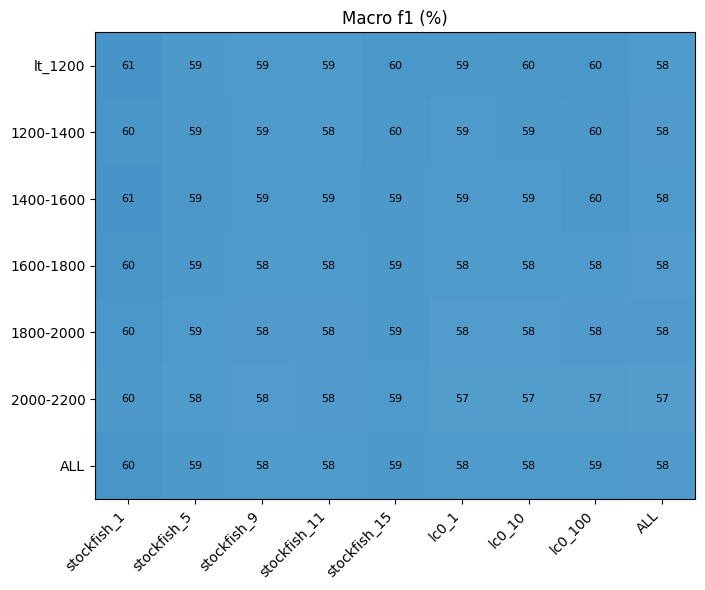

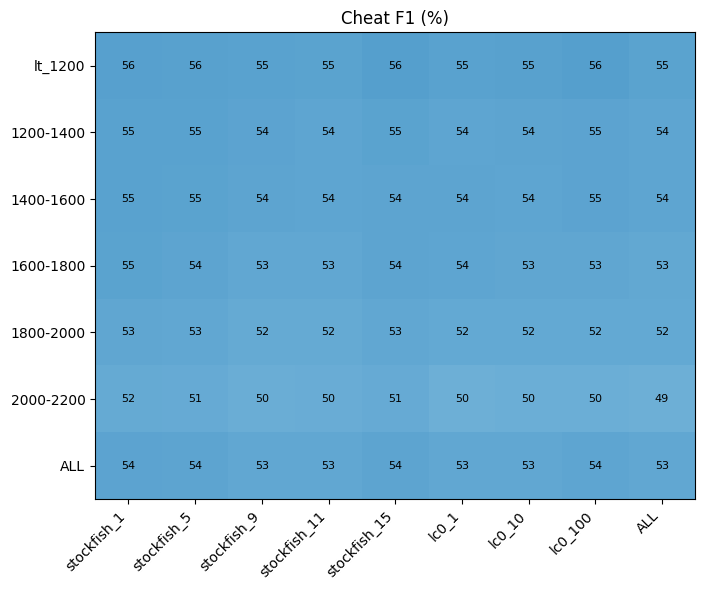

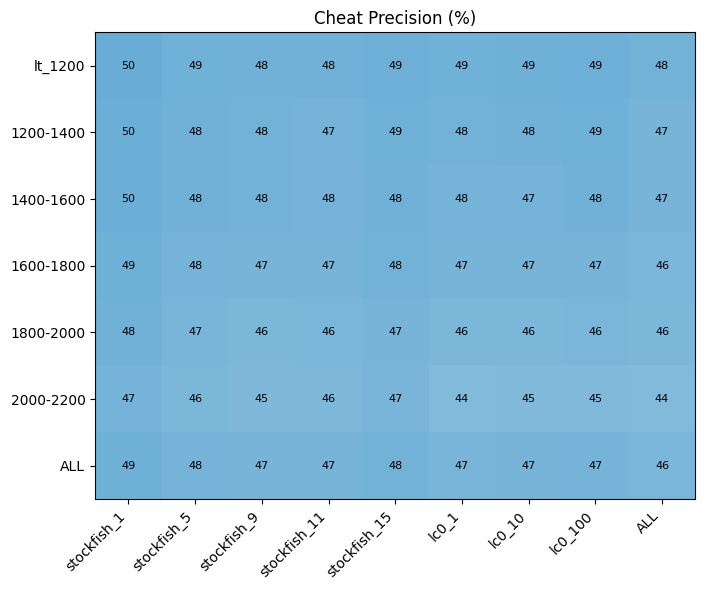

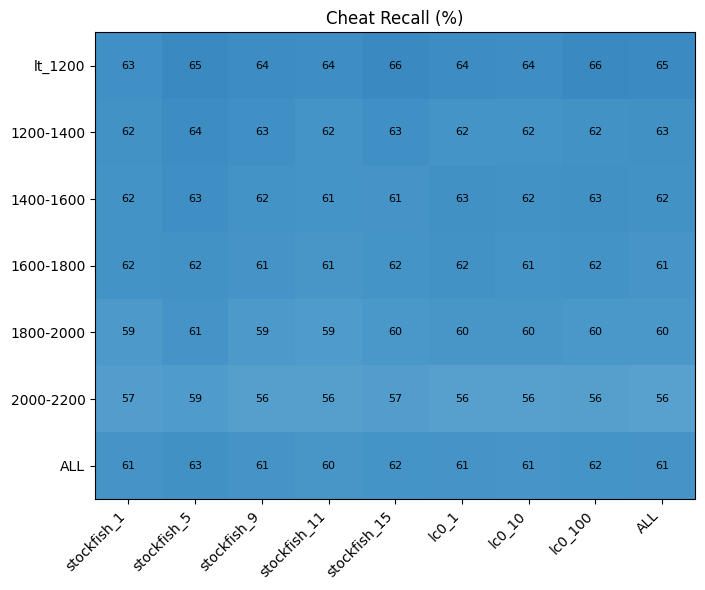

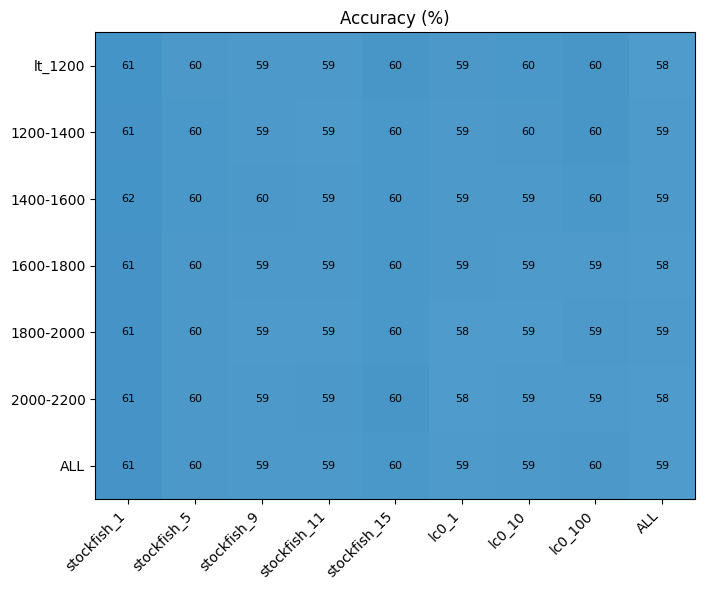

In [21]:
# === Optional: quick heatmaps ===
import matplotlib.pyplot as plt

def plot_metric_heatmap(
    tbl: pd.DataFrame,
    *,
    title: str,
    out_path: Path,
    vmin: float = 0.0,
    vmax: float = 1.0,
    figsize: tuple[int, int] = (10, 6),
    show_values: bool = True,
) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)

    mat = tbl.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)
    _im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="Blues", interpolation="nearest")

    ax.set_xticks(range(tbl.shape[1]))
    ax.set_yticks(range(tbl.shape[0]))
    ax.set_xticklabels([str(c) for c in tbl.columns], rotation=45, ha="right")
    ax.set_yticklabels([str(r) for r in tbl.index])
    ax.set_title(title)

    if show_values:
        for i in range(tbl.shape[0]):
            for j in range(tbl.shape[1]):
                v = mat[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v*100:.0f}", ha="center", va="center", fontsize=8, color="black")

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

PLOTS_DIR = OUT_DIR / "tables" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plot_metric_heatmap(
    tables["macro_f1"],
    title="Macro f1 (%)",
    out_path=PLOTS_DIR / "heatmap__macro_f1.png",
    figsize=(max(10, 0.6 * len(tables["macro_f1"].columns)), max(6, 0.45 * len(tables["macro_f1"].index))),
)

plot_metric_heatmap(
    tables["cheat_f1"],
    title="Cheat F1 (%)",
    out_path=PLOTS_DIR / "heatmap__cheat_f1.png",
    figsize=(max(10, 0.6 * len(tables["cheat_f1"].columns)), max(6, 0.45 * len(tables["cheat_f1"].index))),
)

plot_metric_heatmap(
    tables["cheat_precision"],
    title="Cheat Precision (%)",
    out_path=PLOTS_DIR / "heatmap__cheat_precision.png",
    figsize=(max(10, 0.6 * len(tables["cheat_precision"].columns)), max(6, 0.45 * len(tables["cheat_precision"].index))),
)

plot_metric_heatmap(
    tables["cheat_recall"],
    title="Cheat Recall (%)",
    out_path=PLOTS_DIR / "heatmap__cheat_recall.png",
    figsize=(max(10, 0.6 * len(tables["cheat_recall"].columns)), max(6, 0.45 * len(tables["cheat_recall"].index))),
)

plot_metric_heatmap(
    tables["accuracy"],
    title="Accuracy (%)",
    out_path=PLOTS_DIR / "heatmap__accuracy.png",
    figsize=(max(10, 0.6 * len(tables["accuracy"].columns)), max(6, 0.45 * len(tables["accuracy"].index))),
)
